# Flight Patterns

The `flight_patterns` module provides generators for common atmospheric sampling
patterns. Each generator returns an ordered list of `Waypoint` objects that flow
directly into `compute_flight_plan()`.

Four generators consolidate the functionality of MovingLines' 34 `.flt` modules:

| Generator | Patterns covered |
|-----------|-----------------|
| `racetrack()` | Racetrack, lawnmower, bowling alley, vertical wall, stacked patterns |
| `rosette()` | Rosette, cross, bow-tie, single out-and-back |
| `polygon()` | Square orbit, rectangle, hexagon, triangle, circle |
| `sawtooth()` | Sawtooth altitude profiles, porpoising |

Plus `flight_lines_to_waypoint_path()` to convert existing `FlightLine` objects
into waypoint paths.

We cover:
1. Racetrack patterns (single, multi-leg, lawnmower, stacked)
2. Rosette patterns (3-petal, cross, bow-tie)
3. Polygon orbits (square, rectangle, circle)
4. Sawtooth altitude profiles
5. Vertical walls and altitude variations
6. Converting flight lines to waypoint paths
7. Integration with `compute_flight_plan()`

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt

from hyplan import ureg
from hyplan.flight_patterns import (
    racetrack, rosette, polygon, sawtooth, spiral, flight_lines_to_waypoint_path,
    coordinated_line,
)

# Common center point (Edwards AFB area)
CENTER = (34.9, -117.9)
ALT = ureg.Quantity(20000, "feet")


def plot_pattern(waypoints, ax=None, title=None, show_labels=True, color="C0"):
    """Plot a waypoint pattern on a map-like axes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    lats = [wp.latitude for wp in waypoints]
    lons = [wp.longitude for wp in waypoints]
    ax.plot(lons, lats, "-o", color=color, markersize=4, linewidth=1.5)
    # Start marker
    ax.plot(lons[0], lats[0], "s", color="green", markersize=8, zorder=5, label="Start")
    # End marker
    ax.plot(lons[-1], lats[-1], "D", color="red", markersize=8, zorder=5, label="End")
    # Heading arrows at each waypoint
    for wp in waypoints:
        dx = 0.003 * np.sin(np.radians(wp.heading))
        dy = 0.003 * np.cos(np.radians(wp.heading))
        ax.annotate("", xy=(wp.longitude + dx, wp.latitude + dy),
                    xytext=(wp.longitude, wp.latitude),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.2))
    if show_labels:
        for i, wp in enumerate(waypoints):
            ax.annotate(wp.name, (wp.longitude, wp.latitude),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7, alpha=0.7)
    if title:
        ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    return ax

## 1. Racetrack Patterns

`racetrack()` is the workhorse generator. By varying `n_legs`, `offset`,
`altitudes`, and `stack_altitudes`, it produces racetracks, lawnmowers,
bowling alleys, vertical walls, and stacked patterns.

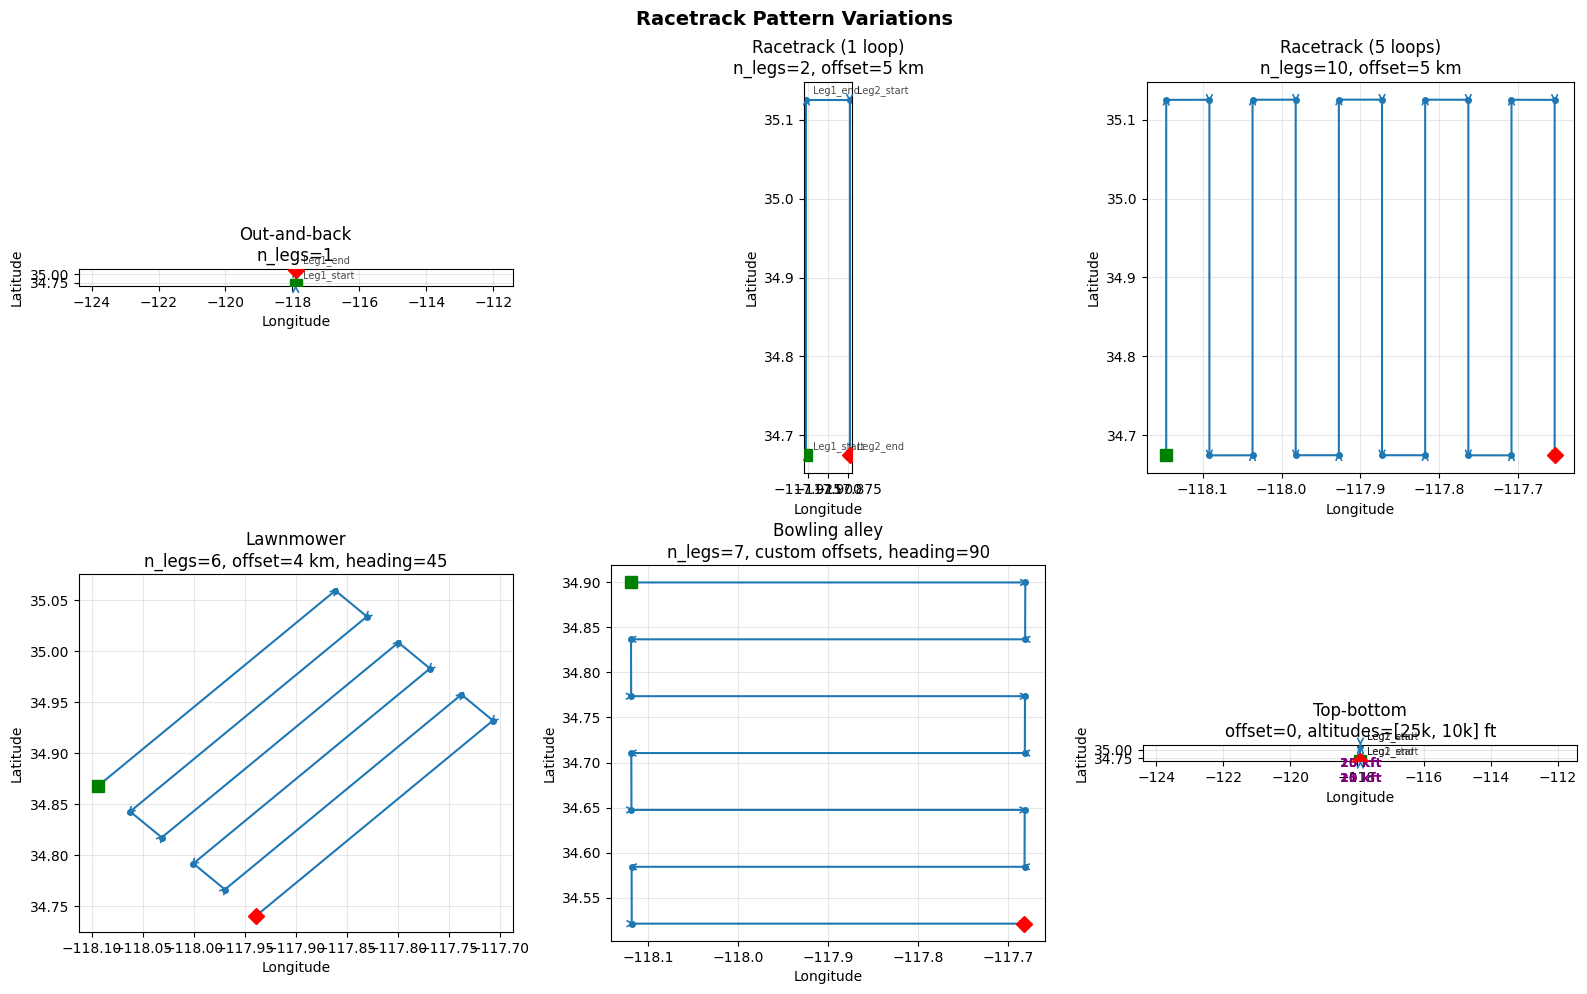

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Single out-and-back
wps = racetrack(CENTER, 0.0, ALT, ureg.Quantity(50, "km"))
plot_pattern(wps, axes[0, 0], "Out-and-back\nn_legs=1")

# Classic racetrack (2 legs = 1 loop)
wps = racetrack(CENTER, 0.0, ALT, ureg.Quantity(50, "km"),
                n_legs=2, offset=ureg.Quantity(5, "km"))
plot_pattern(wps, axes[0, 1], "Racetrack (1 loop)\nn_legs=2, offset=5 km")

# 5-loop racetrack
wps = racetrack(CENTER, 0.0, ALT, ureg.Quantity(50, "km"),
                n_legs=10, offset=ureg.Quantity(5, "km"))
plot_pattern(wps, axes[0, 2], "Racetrack (5 loops)\nn_legs=10, offset=5 km", show_labels=False)

# Lawnmower
wps = racetrack(CENTER, 45.0, ALT, ureg.Quantity(30, "km"),
                n_legs=6, offset=ureg.Quantity(4, "km"))
plot_pattern(wps, axes[1, 0], "Lawnmower\nn_legs=6, offset=4 km, heading=45", show_labels=False)

# Bowling alley (non-uniform offsets)
offsets = [0, 7000, 14000, 21000, 28000, 35000, 42000]
wps = racetrack(CENTER, 90.0, ALT, ureg.Quantity(40, "km"),
                n_legs=7, offset=offsets)
plot_pattern(wps, axes[1, 1], "Bowling alley\nn_legs=7, custom offsets, heading=90", show_labels=False)

# Top-bottom (2 legs, same track, different altitudes)
wps = racetrack(CENTER, 0.0, ALT, ureg.Quantity(50, "km"),
                n_legs=2, offset=0,
                altitudes=[ureg.Quantity(25000, "feet"), ureg.Quantity(10000, "feet")])
plot_pattern(wps, axes[1, 2], "Top-bottom\noffset=0, altitudes=[25k, 10k] ft")
# Annotate altitudes
for wp in wps:
    alt_kft = wp.altitude_msl.to(ureg.foot).magnitude / 1000
    axes[1, 2].annotate(f"{alt_kft:.0f} kft", (wp.longitude, wp.latitude),
                        textcoords="offset points", xytext=(-15, -15),
                        fontsize=9, color="purple", fontweight="bold")

plt.suptitle("Racetrack Pattern Variations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Stacked Racetracks

`stack_altitudes` repeats the entire pattern at multiple altitudes, producing
a 3D sampling volume. This is common for profiling the boundary layer or
building up vertical cross-sections.

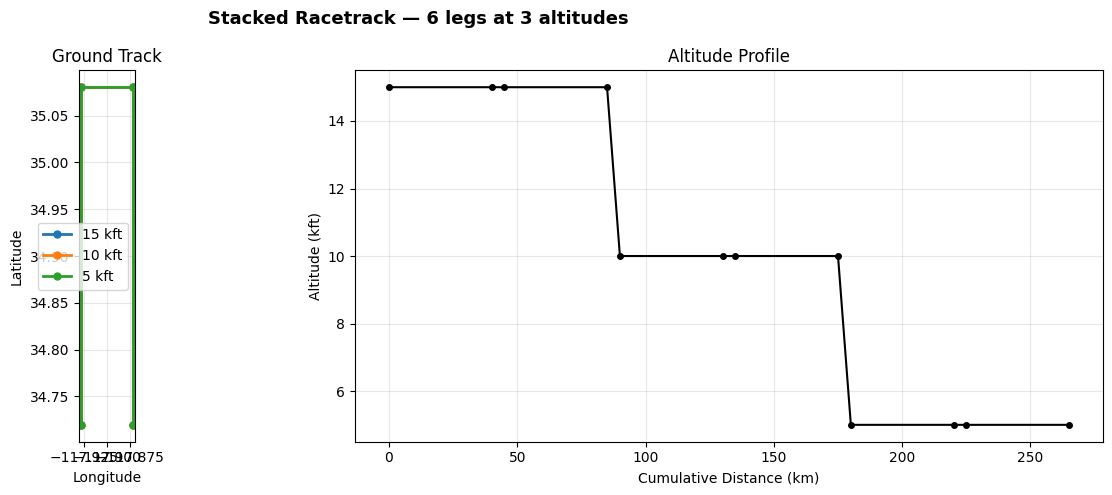

Total waypoints: 12
Pattern: 2 legs x 3 altitudes = 6 legs


In [3]:
stack_alts = [ureg.Quantity(a, "feet") for a in [15000, 10000, 5000]]
wps = racetrack(CENTER, 0.0, ALT, ureg.Quantity(40, "km"),
                n_legs=2, offset=ureg.Quantity(5, "km"),
                stack_altitudes=stack_alts)

fig = plt.figure(figsize=(14, 5))

# Ground track (2D)
ax1 = fig.add_subplot(121)
colors_stack = ["C0", "C1", "C2"]
for level in range(3):
    level_wps = wps[level*4:(level+1)*4]
    alt_kft = level_wps[0].altitude_msl.to(ureg.foot).magnitude / 1000
    lats = [wp.latitude for wp in level_wps]
    lons = [wp.longitude for wp in level_wps]
    ax1.plot(lons, lats, "-o", color=colors_stack[level], markersize=5,
             linewidth=2, label=f"{alt_kft:.0f} kft")
ax1.set_title("Ground Track")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.legend()
ax1.set_aspect("equal")
ax1.grid(True, alpha=0.3)

# Altitude profile
ax2 = fig.add_subplot(122)
import pymap3d.vincenty
cumulative_dist = [0]
alts_ft = [wps[0].altitude_msl.to(ureg.foot).magnitude]
for i in range(1, len(wps)):
    d, _ = pymap3d.vincenty.vdist(
        wps[i-1].latitude, wps[i-1].longitude,
        wps[i].latitude, wps[i].longitude
    )
    cumulative_dist.append(cumulative_dist[-1] + d / 1000)  # km
    alts_ft.append(wps[i].altitude_msl.to(ureg.foot).magnitude)

ax2.plot(cumulative_dist, [a/1000 for a in alts_ft], "k-o", markersize=4)
ax2.set_xlabel("Cumulative Distance (km)")
ax2.set_ylabel("Altitude (kft)")
ax2.set_title("Altitude Profile")
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Stacked Racetrack — {len(wps)//2} legs at 3 altitudes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total waypoints: {len(wps)}")
print(f"Pattern: 2 legs x 3 altitudes = {len(wps)//2} legs")

## 2. Rosette Patterns

`rosette()` generates radial lines through a center point. Each line is a
full diameter — the aircraft flies from a tip on one side, through center,
to the opposite tip. Useful for characterizing spatial gradients radiating
from a source or measuring wind-dependent properties at multiple angles.

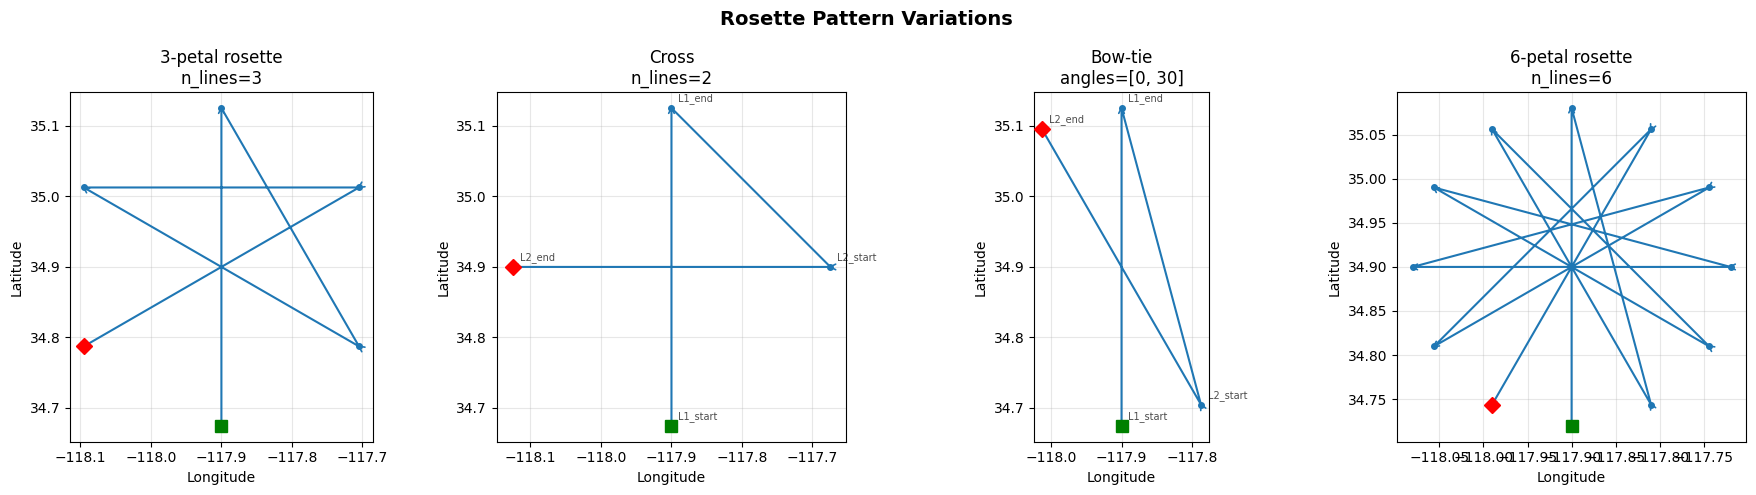

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# 3-petal rosette (default)
wps = rosette(CENTER, 0.0, ALT, ureg.Quantity(25, "km"))
plot_pattern(wps, axes[0], "3-petal rosette\nn_lines=3", show_labels=False)

# Cross (2 lines at 90 degrees)
wps = rosette(CENTER, 0.0, ALT, ureg.Quantity(25, "km"), n_lines=2)
plot_pattern(wps, axes[1], "Cross\nn_lines=2")

# Bow-tie (custom angles)
wps = rosette(CENTER, 0.0, ALT, ureg.Quantity(25, "km"),
              angles=[0.0, 30.0])
plot_pattern(wps, axes[2], "Bow-tie\nangles=[0, 30]")

# 6-petal rosette
wps = rosette(CENTER, 0.0, ALT, ureg.Quantity(20, "km"), n_lines=6)
plot_pattern(wps, axes[3], "6-petal rosette\nn_lines=6", show_labels=False)

plt.suptitle("Rosette Pattern Variations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Polygon Orbits

`polygon()` generates regular polygon perimeters. It replaces separate
`rectangle()` and `circle()` generators — a circle is simply `polygon(n_sides=36)`.

The `aspect_ratio` parameter stretches the polygon along the heading axis,
turning a square into a rectangle or a circle into an ellipse.

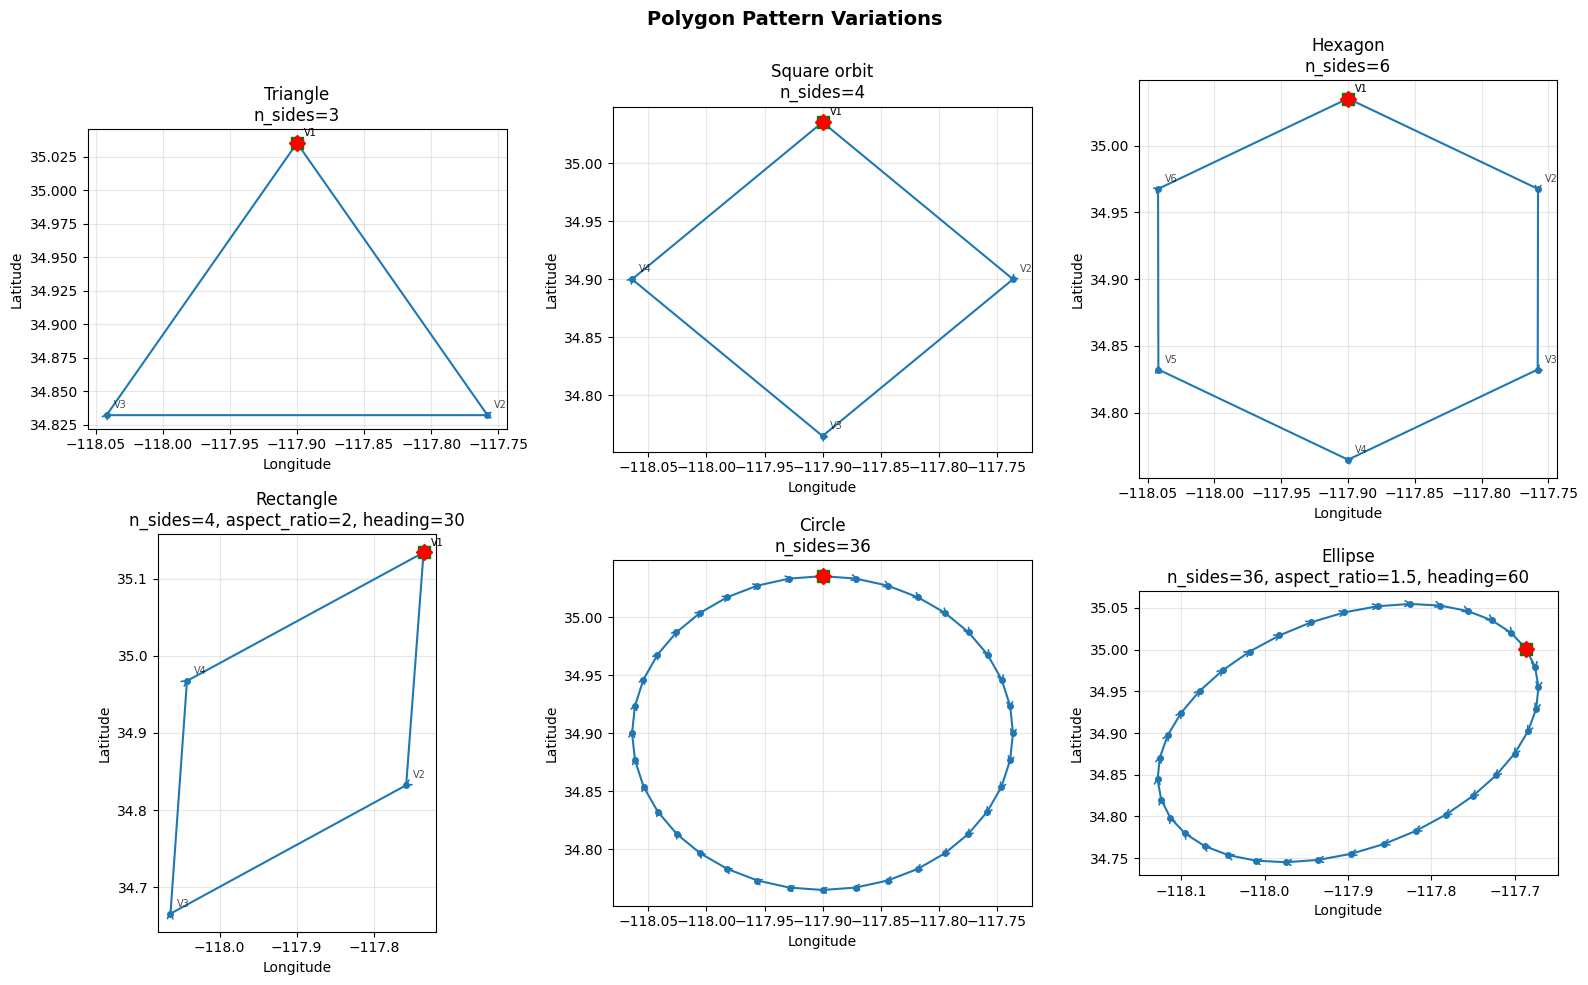

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Triangle
wps = polygon(CENTER, 0.0, ALT, ureg.Quantity(15, "km"), n_sides=3)
plot_pattern(wps, axes[0, 0], "Triangle\nn_sides=3")

# Square
wps = polygon(CENTER, 0.0, ALT, ureg.Quantity(15, "km"), n_sides=4)
plot_pattern(wps, axes[0, 1], "Square orbit\nn_sides=4")

# Hexagon
wps = polygon(CENTER, 0.0, ALT, ureg.Quantity(15, "km"), n_sides=6)
plot_pattern(wps, axes[0, 2], "Hexagon\nn_sides=6")

# Rectangle (aspect_ratio=2)
wps = polygon(CENTER, 30.0, ALT, ureg.Quantity(15, "km"),
              n_sides=4, aspect_ratio=2.0)
plot_pattern(wps, axes[1, 0], "Rectangle\nn_sides=4, aspect_ratio=2, heading=30")

# Circle (n_sides=36)
wps = polygon(CENTER, 0.0, ALT, ureg.Quantity(15, "km"), n_sides=36)
plot_pattern(wps, axes[1, 1], "Circle\nn_sides=36", show_labels=False)

# Ellipse (circle + aspect ratio)
wps = polygon(CENTER, 60.0, ALT, ureg.Quantity(15, "km"),
              n_sides=36, aspect_ratio=1.5)
plot_pattern(wps, axes[1, 2], "Ellipse\nn_sides=36, aspect_ratio=1.5, heading=60",
             show_labels=False)

plt.suptitle("Polygon Pattern Variations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Sawtooth Altitude Profiles

`sawtooth()` generates an oscillating altitude profile along a straight
track. The aircraft porpoises between `altitude_min` and `altitude_max`,
sampling the vertical structure of the atmosphere along a transect.

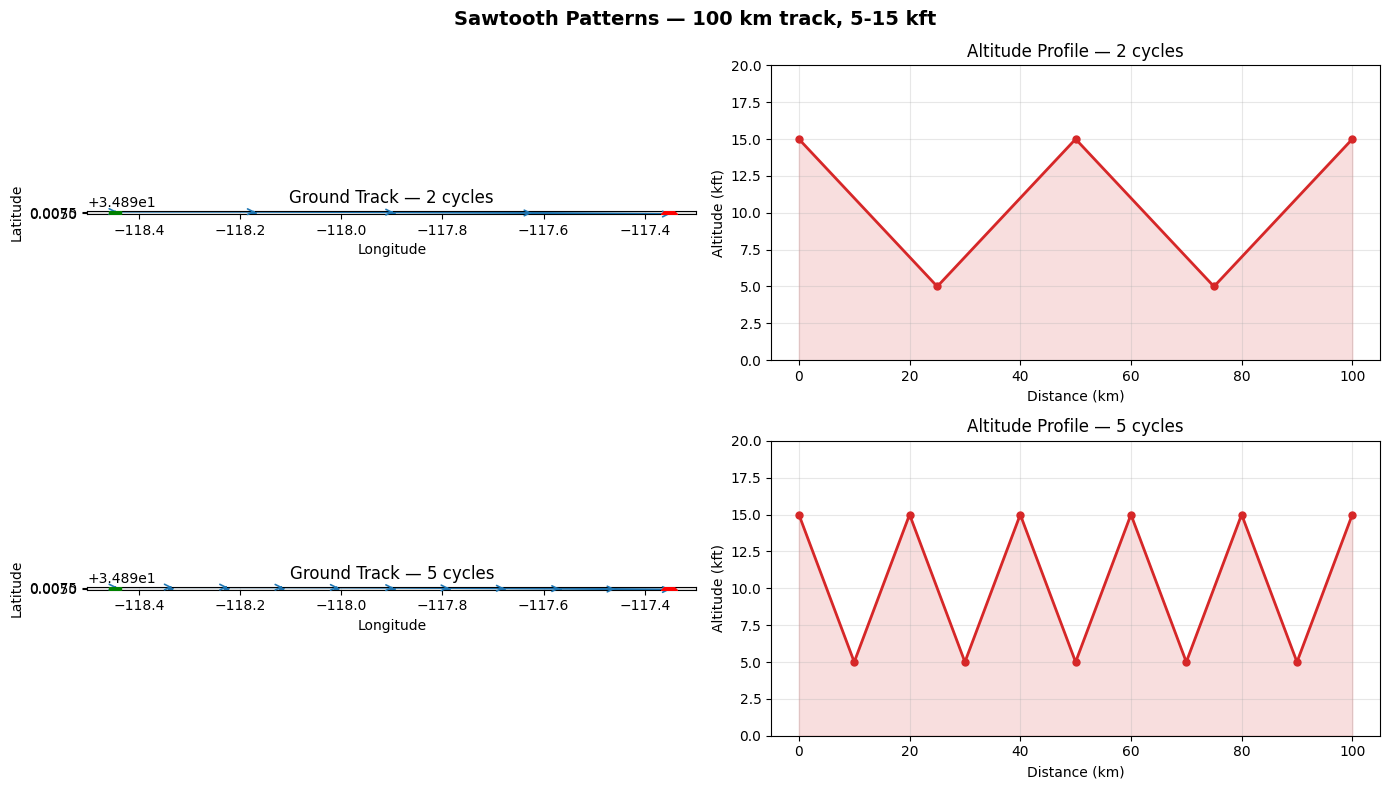

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax_row, n_cyc, title in [
    (axes[0], 2, "2 cycles"),
    (axes[1], 5, "5 cycles"),
]:
    alt_min = ureg.Quantity(5000, "feet")
    alt_max = ureg.Quantity(15000, "feet")
    wps = sawtooth(CENTER, 90.0, alt_min, alt_max,
                   ureg.Quantity(100, "km"), n_cycles=n_cyc)

    # Ground track
    plot_pattern(wps, ax_row[0], f"Ground Track — {title}", show_labels=False)

    # Altitude profile
    cumulative_dist = [0]
    alts_kft = [wps[0].altitude_msl.to(ureg.foot).magnitude / 1000]
    for i in range(1, len(wps)):
        d, _ = pymap3d.vincenty.vdist(
            wps[i-1].latitude, wps[i-1].longitude,
            wps[i].latitude, wps[i].longitude
        )
        cumulative_dist.append(cumulative_dist[-1] + d / 1000)
        alts_kft.append(wps[i].altitude_msl.to(ureg.foot).magnitude / 1000)

    ax_row[1].plot(cumulative_dist, alts_kft, "C3-o", markersize=5, linewidth=2)
    ax_row[1].fill_between(cumulative_dist, alts_kft, alpha=0.15, color="C3")
    ax_row[1].set_xlabel("Distance (km)")
    ax_row[1].set_ylabel("Altitude (kft)")
    ax_row[1].set_title(f"Altitude Profile — {title}")
    ax_row[1].grid(True, alpha=0.3)
    ax_row[1].set_ylim(0, 20)

plt.suptitle("Sawtooth Patterns — 100 km track, 5-15 kft", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Vertical Wall

A vertical wall samples the same ground track at multiple altitudes.
This is achieved with `racetrack(offset=0, altitudes=[...])`.
Combined with `stack_altitudes`, you can build 3D sampling grids.

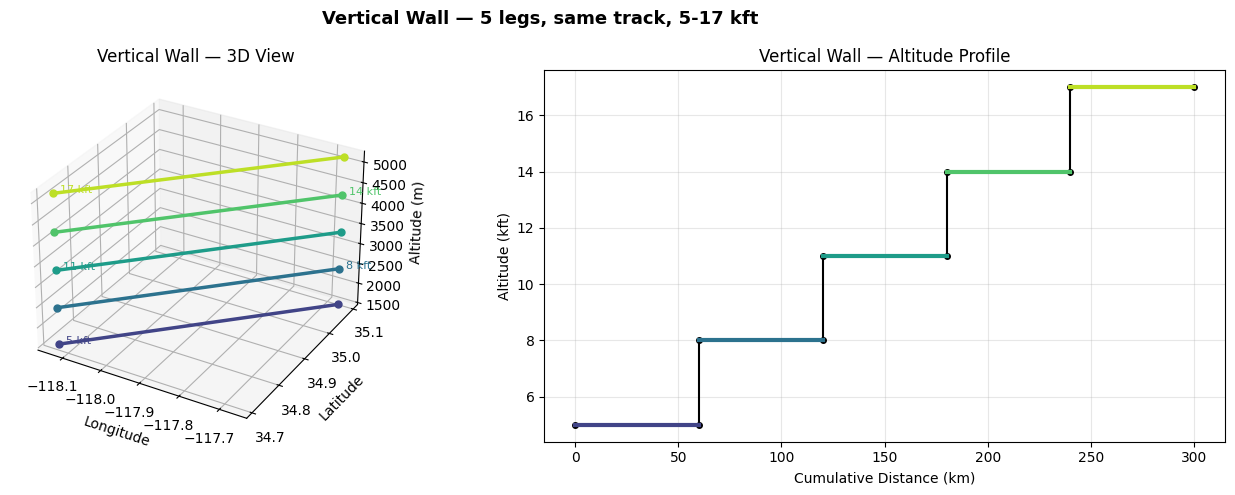

In [7]:
alts = [ureg.Quantity(a, "feet") for a in [5000, 8000, 11000, 14000, 17000]]
wps = racetrack(CENTER, 45.0, alts[0], ureg.Quantity(60, "km"),
                n_legs=5, offset=0, altitudes=alts)

fig = plt.figure(figsize=(14, 5))

# 3D view
ax3d = fig.add_subplot(121, projection="3d")
colors_wall = plt.cm.viridis(np.linspace(0.2, 0.9, 5))
for i in range(5):
    leg_wps = wps[2*i:2*i+2]
    lons = [wp.longitude for wp in leg_wps]
    lats = [wp.latitude for wp in leg_wps]
    alts_m = [wp.altitude_msl.to(ureg.meter).magnitude for wp in leg_wps]
    ax3d.plot(lons, lats, alts_m, "-o", color=colors_wall[i],
              linewidth=2.5, markersize=5)
    alt_kft = leg_wps[0].altitude_msl.to(ureg.foot).magnitude / 1000
    ax3d.text(lons[0], lats[0], alts_m[0], f"  {alt_kft:.0f} kft",
              fontsize=8, color=colors_wall[i])

ax3d.set_xlabel("Longitude")
ax3d.set_ylabel("Latitude")
ax3d.set_zlabel("Altitude (m)")
ax3d.set_title("Vertical Wall — 3D View")

# Altitude profile
ax2 = fig.add_subplot(122)
cumulative_dist = [0]
alts_kft = [wps[0].altitude_msl.to(ureg.foot).magnitude / 1000]
for i in range(1, len(wps)):
    d, _ = pymap3d.vincenty.vdist(
        wps[i-1].latitude, wps[i-1].longitude,
        wps[i].latitude, wps[i].longitude
    )
    cumulative_dist.append(cumulative_dist[-1] + d / 1000)
    alts_kft.append(wps[i].altitude_msl.to(ureg.foot).magnitude / 1000)

ax2.plot(cumulative_dist, alts_kft, "k-o", markersize=4, linewidth=1.5)
for i in range(5):
    d0, d1 = cumulative_dist[2*i], cumulative_dist[2*i+1]
    a = alts_kft[2*i]
    ax2.plot([d0, d1], [a, a], linewidth=3, color=colors_wall[i])
ax2.set_xlabel("Cumulative Distance (km)")
ax2.set_ylabel("Altitude (kft)")
ax2.set_title("Vertical Wall — Altitude Profile")
ax2.grid(True, alpha=0.3)

plt.suptitle("Vertical Wall — 5 legs, same track, 5-17 kft",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5b. Spiral Patterns

Helical vertical profiling — the aircraft flies a constant-radius circle while ascending or descending through the atmosphere. Used for boundary layer profiling, aerosol vertical structure, and thermodynamic soundings.

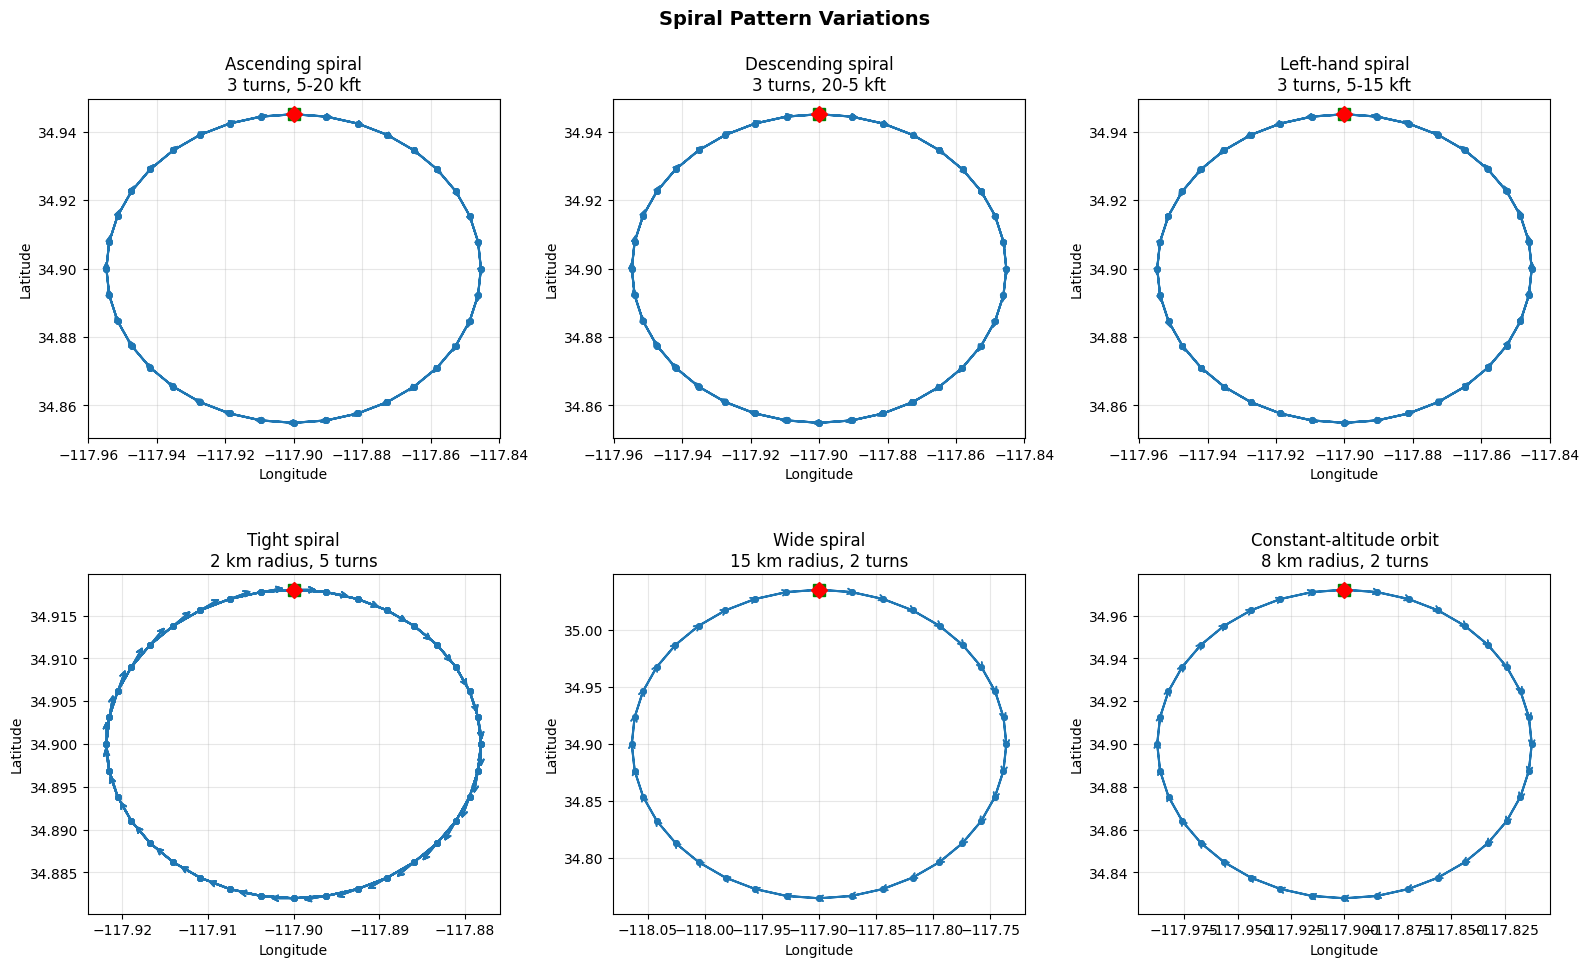

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Basic ascending spiral
wps = spiral(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(20000, "feet"),
             ureg.Quantity(5, "km"), n_turns=3)
plot_pattern(wps, axes[0, 0], "Ascending spiral\n3 turns, 5-20 kft", show_labels=False)

# Descending spiral
wps = spiral(CENTER, 0.0, ureg.Quantity(20000, "feet"), ureg.Quantity(5000, "feet"),
             ureg.Quantity(5, "km"), n_turns=3)
plot_pattern(wps, axes[0, 1], "Descending spiral\n3 turns, 20-5 kft", show_labels=False)

# Left-hand turns
wps = spiral(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(15000, "feet"),
             ureg.Quantity(5, "km"), n_turns=3, direction="left")
plot_pattern(wps, axes[0, 2], "Left-hand spiral\n3 turns, 5-15 kft", show_labels=False)

# Tight spiral (small radius)
wps = spiral(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(15000, "feet"),
             ureg.Quantity(2, "km"), n_turns=5)
plot_pattern(wps, axes[1, 0], "Tight spiral\n2 km radius, 5 turns", show_labels=False)

# Wide spiral (large radius)
wps = spiral(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(15000, "feet"),
             ureg.Quantity(15, "km"), n_turns=2)
plot_pattern(wps, axes[1, 1], "Wide spiral\n15 km radius, 2 turns", show_labels=False)

# Constant-altitude orbit
wps = spiral(CENTER, 0.0, ALT, ALT,
             ureg.Quantity(8, "km"), n_turns=2)
plot_pattern(wps, axes[1, 2], "Constant-altitude orbit\n8 km radius, 2 turns", show_labels=False)

plt.suptitle("Spiral Pattern Variations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Spiral 3D View

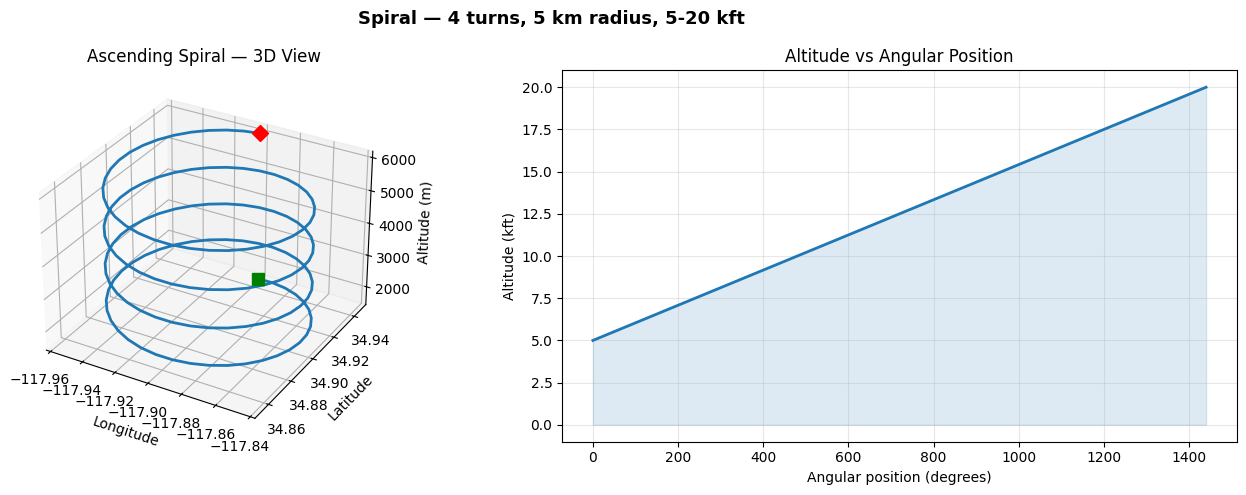

In [9]:
wps = spiral(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(20000, "feet"),
             ureg.Quantity(5, "km"), n_turns=4)

fig = plt.figure(figsize=(14, 5))

# 3D view
ax3d = fig.add_subplot(121, projection="3d")
lons = [wp.longitude for wp in wps]
lats = [wp.latitude for wp in wps]
alts_m = [wp.altitude_msl.to(ureg.meter).magnitude for wp in wps]
alts_kft = [wp.altitude_msl.to(ureg.foot).magnitude / 1000 for wp in wps]
ax3d.plot(lons, lats, alts_m, "-", color="C0", linewidth=2)
ax3d.plot([lons[0]], [lats[0]], [alts_m[0]], "s", color="green", markersize=8)
ax3d.plot([lons[-1]], [lats[-1]], [alts_m[-1]], "D", color="red", markersize=8)
ax3d.set_xlabel("Longitude")
ax3d.set_ylabel("Latitude")
ax3d.set_zlabel("Altitude (m)")
ax3d.set_title("Ascending Spiral — 3D View")

# Altitude profile vs angular position
ax2 = fig.add_subplot(122)
angles = np.linspace(0, 4 * 360, len(wps))
ax2.plot(angles, alts_kft, "C0-", linewidth=2)
ax2.fill_between(angles, alts_kft, alpha=0.15, color="C0")
ax2.set_xlabel("Angular position (degrees)")
ax2.set_ylabel("Altitude (kft)")
ax2.set_title("Altitude vs Angular Position")
ax2.grid(True, alpha=0.3)

plt.suptitle("Spiral — 4 turns, 5 km radius, 5-20 kft",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Converting Flight Lines to Waypoint Paths

`flight_lines_to_waypoint_path()` bridges the gap between `flight_box.py`
(which generates `FlightLine` objects for lawnmower surveys) and the
flight pattern system (which uses `Waypoint` lists). This lets you feed
`box_around_polygon()` output directly into `compute_flight_plan()` as
pattern waypoints.

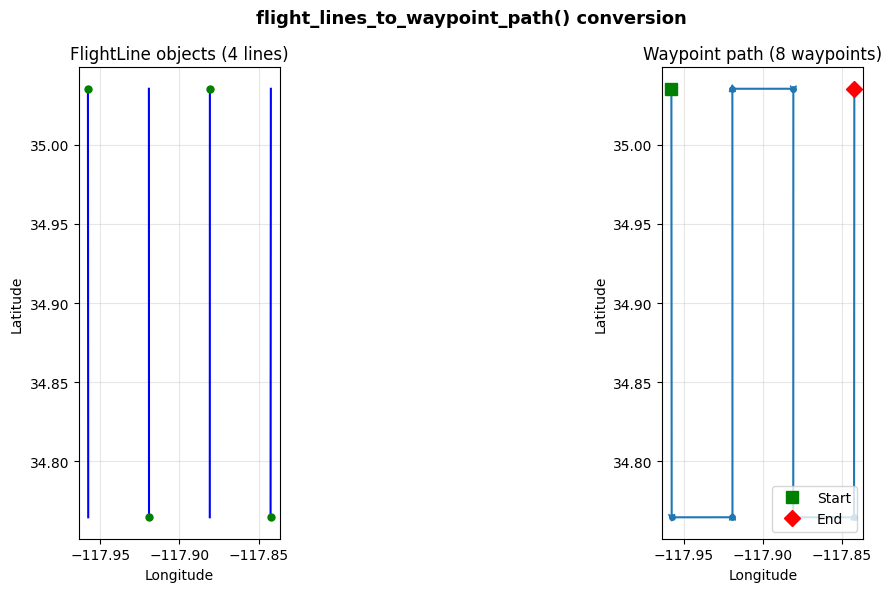

Converted 4 FlightLines -> 8 Waypoints
All segment_type='pattern': False


In [10]:
from hyplan import AVIRIS3, box_around_center_line, FlightLine

sensor = AVIRIS3()
altitude = ureg.Quantity(20000, "feet")

# Generate flight lines from a box
flight_lines = box_around_center_line(
    instrument=sensor,
    altitude_msl=altitude,
    lat0=CENTER[0], lon0=CENTER[1],
    azimuth=0.0,
    box_length=ureg.Quantity(30, "km"),
    box_width=ureg.Quantity(12, "km"),
    overlap=20.0,
    alternate_direction=True,
)

# Convert to waypoint path
wps = flight_lines_to_waypoint_path(flight_lines)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Flight lines view
ax = axes[0]
for fl in flight_lines:
    x, y = fl.geometry.xy
    ax.plot(x, y, "b-", linewidth=1.5)
    ax.plot(x[0], y[0], "go", markersize=5)
ax.set_title(f"FlightLine objects ({len(flight_lines)} lines)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Waypoint path view
plot_pattern(wps, axes[1],
             f"Waypoint path ({len(wps)} waypoints)", show_labels=False)
axes[1].legend(loc="lower right")

plt.suptitle("flight_lines_to_waypoint_path() conversion", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Converted {len(flight_lines)} FlightLines -> {len(wps)} Waypoints")
print(f"All segment_type='pattern': {all(wp.segment_type == 'pattern' for wp in wps)}")

## 7. Integration with `compute_flight_plan()`

Pattern waypoints flow directly into `compute_flight_plan()`. The pipeline
computes Dubins transitions between waypoints, models climb/descent for
altitude changes, and labels segments using the waypoint's `segment_type`.

Below we run each pattern type through the full flight plan pipeline from
Edwards AFB (KEDW), showing the segment table, altitude profile, and
interactive map for each.

In [11]:
from hyplan import DynamicAviation_B200, compute_flight_plan
from hyplan.airports import Airport, initialize_data
import folium

initialize_data(countries=["US"])
b200 = DynamicAviation_B200()
kedw = Airport("KEDW")

SEG_COLORS = {
    "takeoff": "green", "climb": "orange", "transit": "gray",
    "pattern": "blue", "descent": "darkorange", "approach": "red",
    "loiter": "purple",
}


def flight_plan_summary(plan, title=""):
    """Print a segment table and total time/distance."""
    print(f"{'=' * 72}")
    print(f"  {title}")
    print(f"{'=' * 72}")
    print(f"{'Segment Type':<15s} {'Name':<30s} {'Dist (nm)':>10s} {'Time (min)':>10s}")
    print("-" * 68)
    for _, row in plan.iterrows():
        dist = f"{row['distance']:.1f}" if row['distance'] is not None else "—"
        print(f"{row['segment_type']:<15s} {str(row['segment_name']):<30s} {dist:>10s} {row['time_to_segment']:>10.1f}")
    total_time = plan["time_to_segment"].sum()
    total_dist = plan["distance"].dropna().sum()
    print(f"\nTotal: {total_dist:.1f} nm, {total_time:.1f} min ({total_time/60:.1f} hr)")
    return total_time, total_dist


def plot_flight_plan_profile(plan, ax, title=""):
    """Plot altitude vs cumulative time for a flight plan."""
    cum_time = 0
    for _, row in plan.iterrows():
        t = row["time_to_segment"] if row["time_to_segment"] is not None else 0
        color = SEG_COLORS.get(row["segment_type"], "black")
        ax.plot([cum_time, cum_time + t],
                [row["start_altitude"] / 1000, row["end_altitude"] / 1000],
                color=color, linewidth=2.5)
        cum_time += t
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Altitude (kft)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


def map_flight_plan(plan, center, zoom=10):
    """Create a Folium map of a flight plan."""
    m = folium.Map(location=center, zoom_start=zoom, tiles="CartoDB positron")
    for _, row in plan.iterrows():
        geom = row["geometry"]
        color = SEG_COLORS.get(row["segment_type"], "black")
        if geom.geom_type == "LineString":
            coords = [(lat, lon) for lon, lat in geom.coords]
            folium.PolyLine(
                coords, color=color, weight=3, opacity=0.8,
                tooltip=f"{row['segment_type']}: {row['segment_name']}"
            ).add_to(m)
        elif geom.geom_type == "Point":
            folium.CircleMarker(
                [geom.y, geom.x], radius=5, color=color,
                tooltip=f"{row['segment_type']}: {row['segment_name']}"
            ).add_to(m)
    folium.Marker(
        [kedw.latitude, kedw.longitude],
        tooltip="KEDW", icon=folium.Icon(color="red", icon="plane", prefix="fa"),
    ).add_to(m)
    legend_html = "<div style='position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:10px;border-radius:5px;border:1px solid gray;font-size:12px'>"
    for seg_type, color in SEG_COLORS.items():
        legend_html += f"<span style='color:{color};font-weight:bold'>&#9632;</span> {seg_type}<br>"
    legend_html += "</div>"
    m.get_root().html.add_child(folium.Element(legend_html))
    return m

### 7a. Rosette Flight Plan

  Rosette — 3 lines, 25 km radius, 20 kft
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                            33.0        8.9
pattern         L1_start to L1_end                   27.0        7.3
pattern_turn    L1_end to L2_start                   27.9        7.5
pattern         L2_start to L2_end                   23.5        6.4
pattern_turn    L2_end to L3_start                   24.1        6.5
pattern         L3_start to L3_end                   23.5        6.4
descent         Return                               37.4       11.9

Total: 196.4 nm, 54.8 min (0.9 hr)


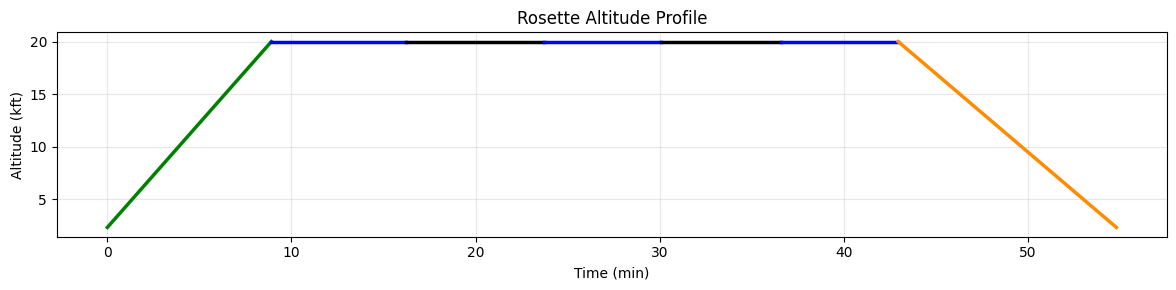

In [12]:
wps_rosette = rosette(CENTER, 0.0, ALT, ureg.Quantity(25, "km"), n_lines=3)
plan_rosette = compute_flight_plan(
    aircraft=b200, flight_sequence=wps_rosette,
    takeoff_airport=kedw, return_airport=kedw,
)

flight_plan_summary(plan_rosette, "Rosette — 3 lines, 25 km radius, 20 kft")

fig, ax = plt.subplots(figsize=(12, 3))
plot_flight_plan_profile(plan_rosette, ax, "Rosette Altitude Profile")
plt.tight_layout()
plt.show()

In [13]:
map_flight_plan(plan_rosette, list(CENTER), zoom=10)

### 7b. Lawnmower Racetrack Flight Plan

A 6-leg lawnmower with 4 km spacing at 20 kft. This is a common remote
sensing survey pattern — note how the flight plan labels the straight
science legs as "pattern" and the turns as "transit".

  Lawnmower — 6 legs, 40 km, 4 km spacing, 20 kft
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                            33.0        8.9
pattern         Leg1_start to Leg1_end               21.6        5.8
pattern_turn    Leg1_end to Leg2_start                5.8        1.6
pattern         Leg2_start to Leg2_end               21.6        5.8
pattern_turn    Leg2_end to Leg3_start                5.7        1.6
pattern         Leg3_start to Leg3_end               21.6        5.8
pattern_turn    Leg3_end to Leg4_start                5.8        1.6
pattern         Leg4_start to Leg4_end               21.6        5.8
pattern_turn    Leg4_end to Leg5_start                5.7        1.6
pattern         Leg5_start to Leg5_end               21.6        5.8
pattern_turn    Leg5_end to Leg6_start                5.8        1.6
pattern         Leg6_start to Leg6_end               

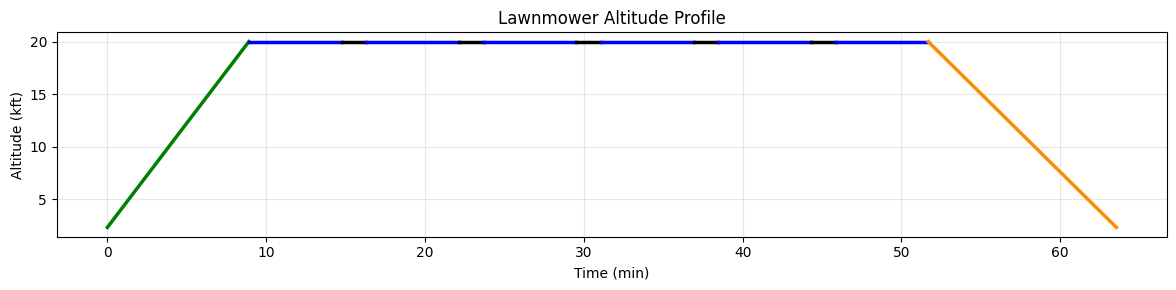

In [14]:
wps_lawn = racetrack(CENTER, 0.0, ALT, ureg.Quantity(40, "km"),
                    n_legs=6, offset=ureg.Quantity(4, "km"))
plan_lawn = compute_flight_plan(
    aircraft=b200, flight_sequence=wps_lawn,
    takeoff_airport=kedw, return_airport=kedw,
)

flight_plan_summary(plan_lawn, "Lawnmower — 6 legs, 40 km, 4 km spacing, 20 kft")

fig, ax = plt.subplots(figsize=(12, 3))
plot_flight_plan_profile(plan_lawn, ax, "Lawnmower Altitude Profile")
plt.tight_layout()
plt.show()

In [15]:
map_flight_plan(plan_lawn, list(CENTER), zoom=10)

### 7c. Rectangle Orbit Flight Plan

A rectangular orbit (4-sided polygon with aspect ratio 2) at 20 kft.
The aircraft flies a closed loop, so the pattern starts and ends at
roughly the same location.

  Rectangle Orbit — 15 km radius, aspect_ratio=2, 20 kft
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                            33.0        8.9
pattern         V1 to V2                             18.1        4.9
pattern         V2 to V3                             18.1        4.9
pattern         V3 to V4                             18.1        4.9
pattern         V4 to V1                             18.1        4.9
descent         Return                               37.4       11.9

Total: 142.8 nm, 40.3 min (0.7 hr)


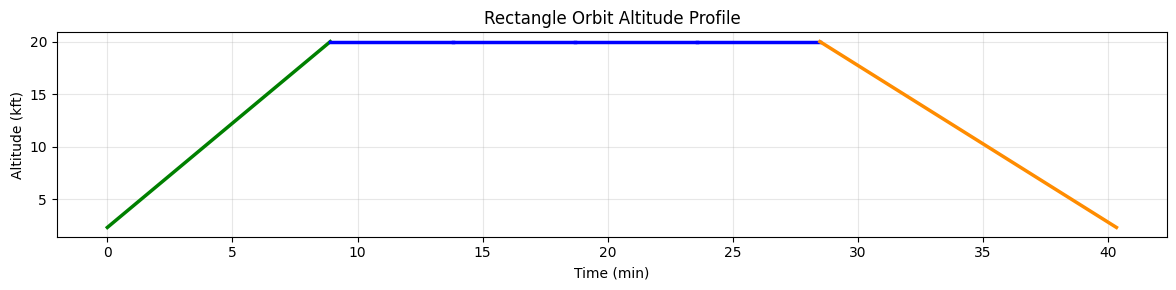

In [16]:
wps_rect = polygon(CENTER, 0.0, ALT, ureg.Quantity(15, "km"),
                   n_sides=4, aspect_ratio=2.0)
plan_rect = compute_flight_plan(
    aircraft=b200, flight_sequence=wps_rect,
    takeoff_airport=kedw, return_airport=kedw,
)

flight_plan_summary(plan_rect, "Rectangle Orbit — 15 km radius, aspect_ratio=2, 20 kft")

fig, ax = plt.subplots(figsize=(12, 3))
plot_flight_plan_profile(plan_rect, ax, "Rectangle Orbit Altitude Profile")
plt.tight_layout()
plt.show()

In [17]:
map_flight_plan(plan_rect, list(CENTER), zoom=10)

### 7d. Sawtooth Flight Plan

A sawtooth porpoising between 5 and 15 kft over 100 km. The altitude
profile shows the climb/descent segments modeled by the aircraft
performance, while the map shows the straight ground track.

  Sawtooth — 3 cycles, 5-15 kft, 100 km track
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                            31.4        8.9
descent         ST1 to ST2                           21.7        6.7
climb           ST2 to ST3                           17.9        5.1
descent         ST3 to ST4                           21.7        6.7
climb           ST4 to ST5                           17.9        5.1
descent         ST5 to ST6                           21.7        6.7
climb           ST6 to ST7                           17.9        5.1
descent         Return                               32.0       10.1

Total: 182.3 nm, 54.3 min (0.9 hr)


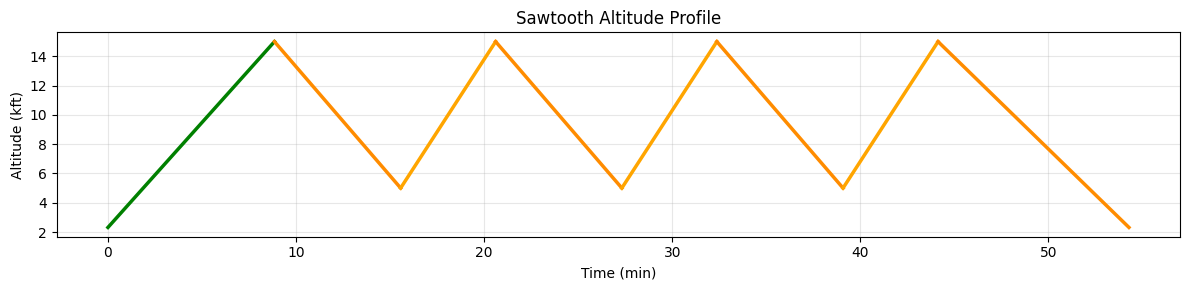

In [18]:
wps_saw = sawtooth(CENTER, 90.0,
                  altitude_min=ureg.Quantity(5000, "feet"),
                  altitude_max=ureg.Quantity(15000, "feet"),
                  leg_length=ureg.Quantity(100, "km"),
                  n_cycles=3)
plan_saw = compute_flight_plan(
    aircraft=b200, flight_sequence=wps_saw,
    takeoff_airport=kedw, return_airport=kedw,
)

flight_plan_summary(plan_saw, "Sawtooth — 3 cycles, 5-15 kft, 100 km track")

fig, ax = plt.subplots(figsize=(12, 3))
plot_flight_plan_profile(plan_saw, ax, "Sawtooth Altitude Profile")
plt.tight_layout()
plt.show()

In [19]:
map_flight_plan(plan_saw, list(CENTER), zoom=10)

### 7e. Stacked Racetrack Flight Plan

A 2-leg racetrack repeated at 15, 10, and 5 kft. The altitude profile
shows the aircraft descending between each stack level. This is a common
boundary layer profiling pattern.

  Stacked Racetrack — 2 legs x 3 altitudes (15/10/5 kft)
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                            22.7        6.4
pattern         Leg1_start to Leg1_end               21.6        6.1
pattern_turn    Leg1_end to Leg2_start                4.0        1.1
pattern         Leg2_start to Leg2_end               21.6        6.1
descent         Leg2_end to Leg3_start               11.4        3.4
pattern         Leg3_start to Leg3_end               21.6        6.4
pattern_turn    Leg3_end to Leg4_start                3.9        1.1
pattern         Leg4_start to Leg4_end               21.6        6.4
descent         Leg4_end to Leg5_start               10.9        3.4
pattern         Leg5_start to Leg5_end               21.6        6.7
pattern_turn    Leg5_end to Leg6_start                3.8        1.2
pattern         Leg6_start to Leg6_end        

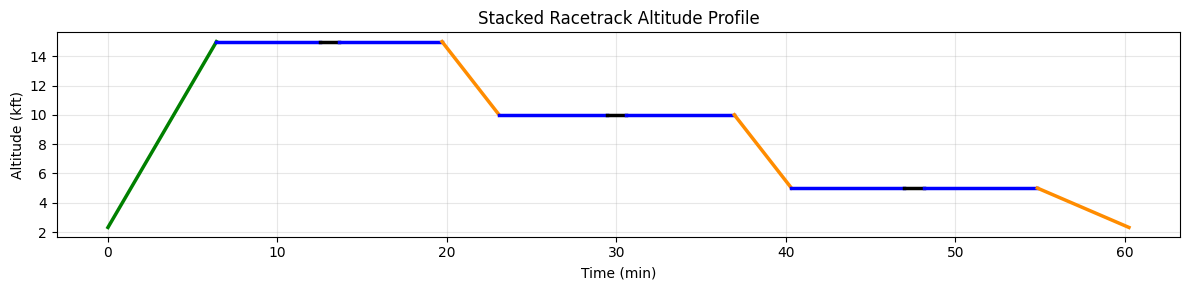

In [20]:
stack_alts = [ureg.Quantity(a, "feet") for a in [15000, 10000, 5000]]
wps_stack = racetrack(CENTER, 0.0, ALT, ureg.Quantity(40, "km"),
                      n_legs=2, offset=ureg.Quantity(5, "km"),
                      stack_altitudes=stack_alts)
plan_stack = compute_flight_plan(
    aircraft=b200, flight_sequence=wps_stack,
    takeoff_airport=kedw, return_airport=kedw,
)

flight_plan_summary(plan_stack, "Stacked Racetrack — 2 legs x 3 altitudes (15/10/5 kft)")

fig, ax = plt.subplots(figsize=(12, 3))
plot_flight_plan_profile(plan_stack, ax, "Stacked Racetrack Altitude Profile")
plt.tight_layout()
plt.show()

In [21]:
map_flight_plan(plan_stack, list(CENTER), zoom=10)

### 7f. Vertical Wall Flight Plan

5 legs along the same ground track at different altitudes (5–17 kft).
The altitude profile clearly shows the step-up pattern with climb
segments between each level leg.

  Vertical Wall — 5 legs, same track, 5-17 kft
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                            20.2        6.2
pattern         Leg1_start to Leg1_end               32.4       10.0
climb           Leg1_end to Leg2_start                7.4        2.2
pattern         Leg2_start to Leg2_end               32.4        9.7
climb           Leg2_end to Leg3_start                7.8        2.3
pattern         Leg3_start to Leg3_end               32.4        9.5
climb           Leg3_end to Leg4_start                8.3        2.4
pattern         Leg4_start to Leg4_end               32.4        9.2
climb           Leg4_end to Leg5_start                8.7        2.4
pattern         Leg5_start to Leg5_end               32.4        9.0
descent         Return                               31.1        9.8

Total: 245.5 nm, 72.8 min (1.2 hr)


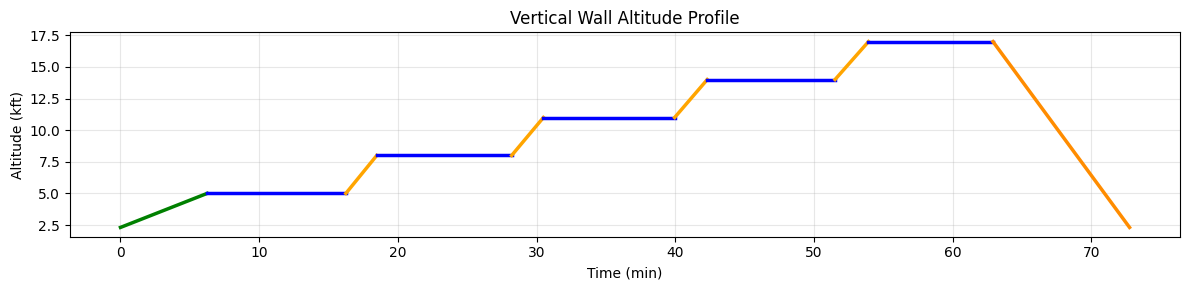

In [22]:
wall_alts = [ureg.Quantity(a, "feet") for a in [5000, 8000, 11000, 14000, 17000]]
wps_wall = racetrack(CENTER, 45.0, wall_alts[0], ureg.Quantity(60, "km"),
                     n_legs=5, offset=0, altitudes=wall_alts)
plan_wall = compute_flight_plan(
    aircraft=b200, flight_sequence=wps_wall,
    takeoff_airport=kedw, return_airport=kedw,
)

flight_plan_summary(plan_wall, "Vertical Wall — 5 legs, same track, 5-17 kft")

fig, ax = plt.subplots(figsize=(12, 3))
plot_flight_plan_profile(plan_wall, ax, "Vertical Wall Altitude Profile")
plt.tight_layout()
plt.show()

In [23]:
map_flight_plan(plan_wall, list(CENTER), zoom=10)

### 7g. Flight Plan Comparison

Side-by-side comparison of all pattern flight plans — altitude profiles
and total flight time/distance.

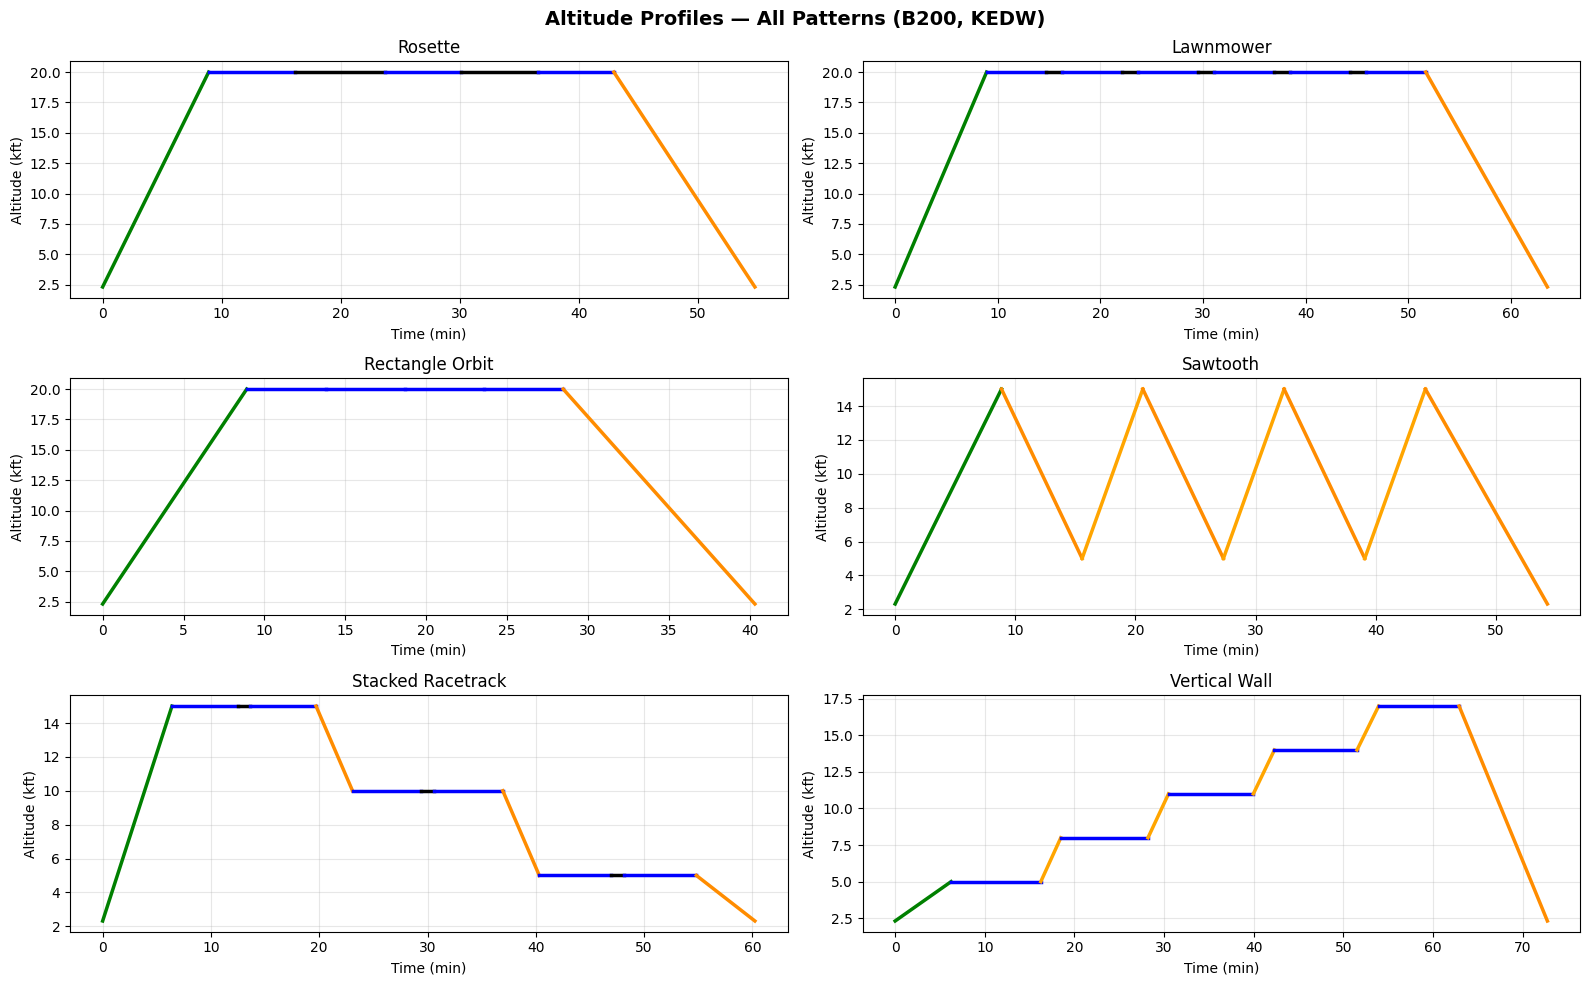


Pattern                Segments  Dist (nm) Time (min)  Time (hr)
--------------------------------------------------------------
Rosette                       7        196         55        0.9
Lawnmower                    13        229         64        1.1
Rectangle Orbit               6        143         40        0.7
Sawtooth                      8        182         54        0.9
Stacked Racetrack            13        203         60        1.0
Vertical Wall                11        245         73        1.2


In [24]:
plans = [
    ("Rosette", plan_rosette),
    ("Lawnmower", plan_lawn),
    ("Rectangle Orbit", plan_rect),
    ("Sawtooth", plan_saw),
    ("Stacked Racetrack", plan_stack),
    ("Vertical Wall", plan_wall),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
for ax, (name, plan) in zip(axes.flat, plans):
    plot_flight_plan_profile(plan, ax, name)

plt.suptitle("Altitude Profiles — All Patterns (B200, KEDW)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Pattern':<22s} {'Segments':>8s} {'Dist (nm)':>10s} {'Time (min)':>10s} {'Time (hr)':>10s}")
print("-" * 62)
for name, plan in plans:
    t = plan["time_to_segment"].sum()
    d = plan["distance"].dropna().sum()
    print(f"{name:<22s} {len(plan):>8d} {d:>10.0f} {t:>10.0f} {t/60:>10.1f}")

### 7h. Spiral Flight Plan

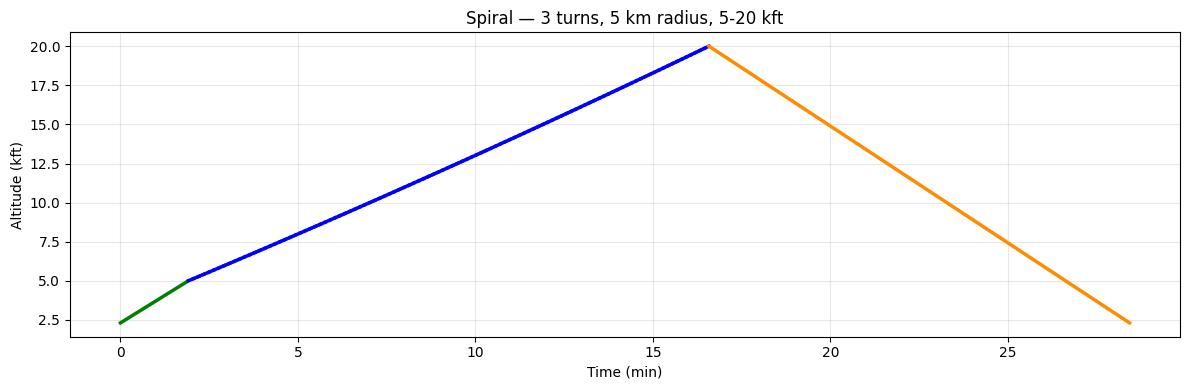

  Spiral Flight Plan
Segment Type    Name                            Dist (nm) Time (min)
--------------------------------------------------------------------
takeoff         Departure                             6.2        1.9
pattern         SP1 to SP2                            0.5        0.1
pattern         SP2 to SP3                            0.5        0.1
pattern         SP3 to SP4                            0.5        0.1
pattern         SP4 to SP5                            0.5        0.1
pattern         SP5 to SP6                            0.5        0.1
pattern         SP6 to SP7                            0.5        0.1
pattern         SP7 to SP8                            0.5        0.1
pattern         SP8 to SP9                            0.5        0.1
pattern         SP9 to SP10                           0.5        0.1
pattern         SP10 to SP11                          0.5        0.1
pattern         SP11 to SP12                          0.5        0.1
pattern      

(np.float64(28.430182684215985), np.float64(94.40270208132628))

In [25]:
wps_spiral = spiral(CENTER, 0.0,
                    altitude_start=ureg.Quantity(5000, "feet"),
                    altitude_end=ureg.Quantity(20000, "feet"),
                    radius=ureg.Quantity(5, "km"),
                    n_turns=3)
plan_spiral = compute_flight_plan(b200, wps_spiral, takeoff_airport=kedw, return_airport=kedw)

fig, ax = plt.subplots(figsize=(12, 4))
plot_flight_plan_profile(plan_spiral, ax, "Spiral — 3 turns, 5 km radius, 5-20 kft")
plt.tight_layout()
plt.show()

flight_plan_summary(plan_spiral, "Spiral Flight Plan")

In [26]:
map_flight_plan(plan_spiral, list(CENTER), zoom=11)

## 8. 3D Dubins Altitude Profiles

`compute_flight_plan()` uses 3D Dubins path planning for all transitions
between waypoints. This produces geometrically accurate paths that account
for altitude changes in the turn geometry.

The aircraft's pitch limits are automatically derived from its climb/descent
rates via `Aircraft.pitch_limits()`.

In [27]:
# Aircraft pitch limits
pitch_min, pitch_max = b200.pitch_limits()
print(f"B200 pitch limits: {pitch_min:.2f}° to {pitch_max:.2f}°")
print(f"  (derived from climb profile and descent profile)")


B200 pitch limits: -3.39° to 4.52°
  (derived from climb profile and descent profile)


### 8a. Sawtooth Altitude Profile

The sawtooth pattern is the ideal test case for 3D Dubins — every transition
involves an altitude change. The 3D Dubins planner produces pitch-constrained
paths that smoothly connect each altitude level.

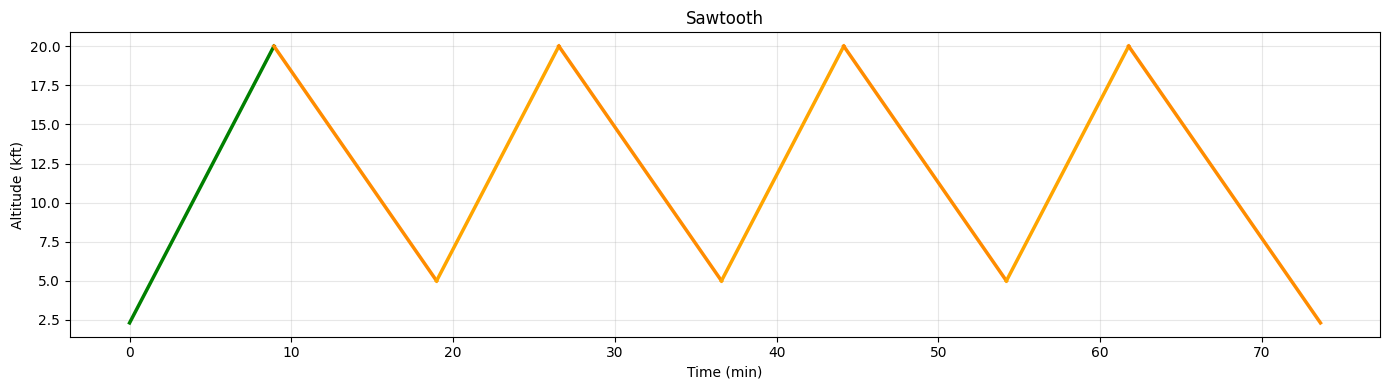

Sawtooth: 252.0 nm, 73.6 min


In [28]:
wps_saw = sawtooth(
    CENTER, 0.0,
    altitude_min=ureg.Quantity(5000, "feet"),
    altitude_max=ureg.Quantity(20000, "feet"),
    leg_length=ureg.Quantity(100, "km"),
    n_cycles=3,
)

plan_saw = compute_flight_plan(b200, wps_saw, takeoff_airport=kedw, return_airport=kedw)

fig, ax = plt.subplots(figsize=(14, 4))
plot_flight_plan_profile(plan_saw, ax, "Sawtooth")
plt.tight_layout()
plt.show()

t = plan_saw["time_to_segment"].sum()
d = plan_saw["distance"].dropna().sum()
print(f"Sawtooth: {d:.1f} nm, {t:.1f} min")

### 8b. Stacked Racetrack with 3D Dubins

A 2-leg racetrack repeated at 20, 15, and 10 kft. The 3D Dubins planner
handles the altitude transitions between stacks with pitch-constrained paths.

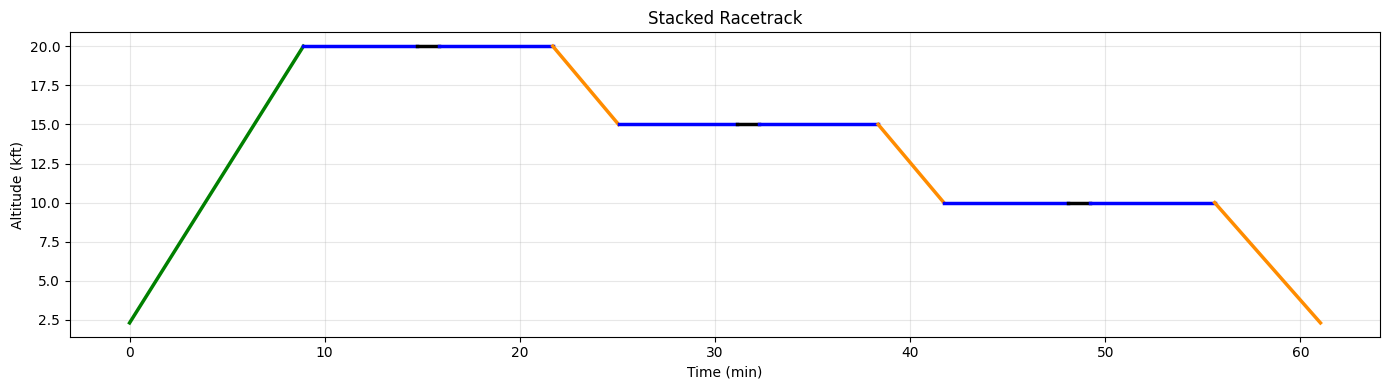

Stacked racetrack: 215.1 nm, 61.0 min


In [29]:
stack_alts = [ureg.Quantity(a, "feet") for a in [20000, 15000, 10000]]
wps_stack = racetrack(
    CENTER, 0.0, ALT, ureg.Quantity(40, "km"),
    n_legs=2, offset=ureg.Quantity(5, "km"),
    stack_altitudes=stack_alts,
)

plan_stack = compute_flight_plan(b200, wps_stack, takeoff_airport=kedw, return_airport=kedw)

fig, ax = plt.subplots(figsize=(14, 4))
plot_flight_plan_profile(plan_stack, ax, "Stacked Racetrack")
plt.tight_layout()
plt.show()

t = plan_stack["time_to_segment"].sum()
d = plan_stack["distance"].dropna().sum()
print(f"Stacked racetrack: {d:.1f} nm, {t:.1f} min")

### 8c. Vertical Wall with 3D Dubins

5 legs on the same ground track at different altitudes. Every transition is a
pure altitude change with no heading change — the 3D Dubins planner produces
smooth pitch-constrained transitions.

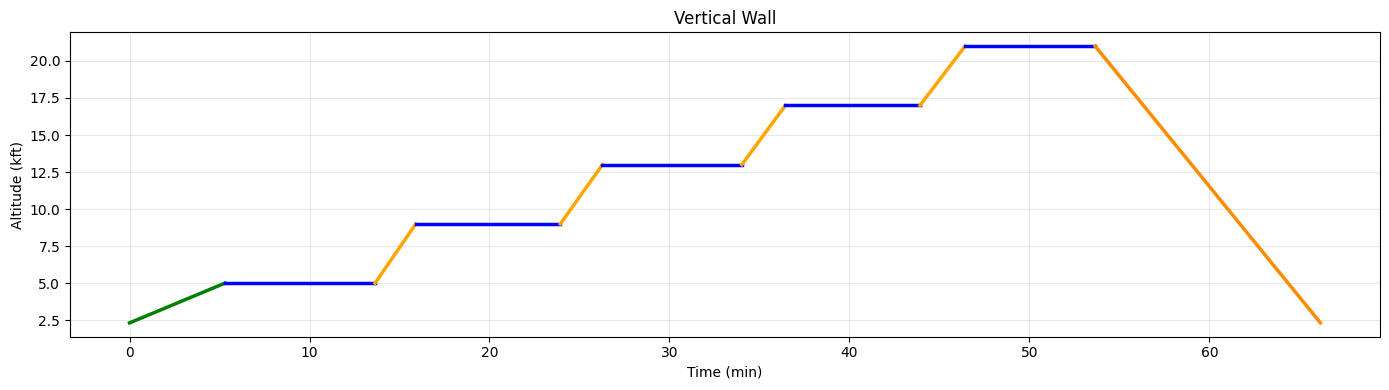

Vertical wall: 225.5 nm, 66.2 min


In [30]:
alts_wall = [ureg.Quantity(a, "feet") for a in [5000, 9000, 13000, 17000, 21000]]
wps_wall = racetrack(
    CENTER, 0.0, alts_wall[0], ureg.Quantity(50, "km"),
    n_legs=5, offset=0, altitudes=alts_wall,
)

plan_wall = compute_flight_plan(b200, wps_wall, takeoff_airport=kedw, return_airport=kedw)

fig, ax = plt.subplots(figsize=(14, 4))
plot_flight_plan_profile(plan_wall, ax, "Vertical Wall")
plt.tight_layout()
plt.show()

t = plan_wall["time_to_segment"].sum()
d = plan_wall["distance"].dropna().sum()
print(f"Vertical wall: {d:.1f} nm, {t:.1f} min")

### 8d. All Patterns — Flight Plan Summary

Total flight time and distance for each pattern type using 3D Dubins
path planning.

In [31]:
import pandas as pd

patterns = {
    "Rosette (3-line, 25 km)": rosette(CENTER, 0.0, ALT, ureg.Quantity(25, "km"), n_lines=3),
    "Lawnmower (6-leg, 4 km)": racetrack(CENTER, 90.0, ALT, ureg.Quantity(30, "km"), n_legs=6, offset=ureg.Quantity(4, "km")),
    "Rectangle orbit": polygon(CENTER, 0.0, ALT, ureg.Quantity(15, "km"), n_sides=4, aspect_ratio=2),
    "Sawtooth (5-20 kft)": sawtooth(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(20000, "feet"), ureg.Quantity(100, "km"), n_cycles=3),
    "Stacked racetrack": racetrack(CENTER, 0.0, ALT, ureg.Quantity(40, "km"), n_legs=2, offset=ureg.Quantity(5, "km"), stack_altitudes=stack_alts),
    "Vertical wall (5 legs)": racetrack(CENTER, 0.0, alts_wall[0], ureg.Quantity(50, "km"), n_legs=5, offset=0, altitudes=alts_wall),
    "Spiral (3 turns, 5-20 kft)": spiral(CENTER, 0.0, ureg.Quantity(5000, "feet"), ureg.Quantity(20000, "feet"), ureg.Quantity(5, "km"), n_turns=3),
}

rows = []
for name, wps in patterns.items():
    plan = compute_flight_plan(b200, wps, takeoff_airport=kedw, return_airport=kedw)
    t = plan["time_to_segment"].sum()
    d = plan["distance"].dropna().sum()
    rows.append({"Pattern": name, "Distance (nm)": round(d, 1), "Time (min)": round(t, 1)})

df = pd.DataFrame(rows).set_index("Pattern")
print(df.to_string())

                            Distance (nm)  Time (min)
Pattern                                              
Rosette (3-line, 25 km)             196.4        54.8
Lawnmower (6-leg, 4 km)             196.3        54.8
Rectangle orbit                     142.8        40.3
Sawtooth (5-20 kft)                 252.0        73.6
Stacked racetrack                   215.1        61.0
Vertical wall (5 legs)              225.5        66.2
Spiral (3 turns, 5-20 kft)           94.4        28.4


## 9. Coordinated Dual-Aircraft Line (Five-Point Line)

The `coordinated_line()` generator implements the IMPACTS five-point line
pattern (Yorks et al. 2025, BAMS). Two aircraft fly vertically stacked legs
centered on a coordination point — the secondary (faster) aircraft's leg is
extended so both platforms pass over the center simultaneously.

Ground speed ratio: 1.36
P-3 waypoints: ['P3_start', 'P3_end']
ER-2 waypoints: ['ER2_start', 'ER2_end']


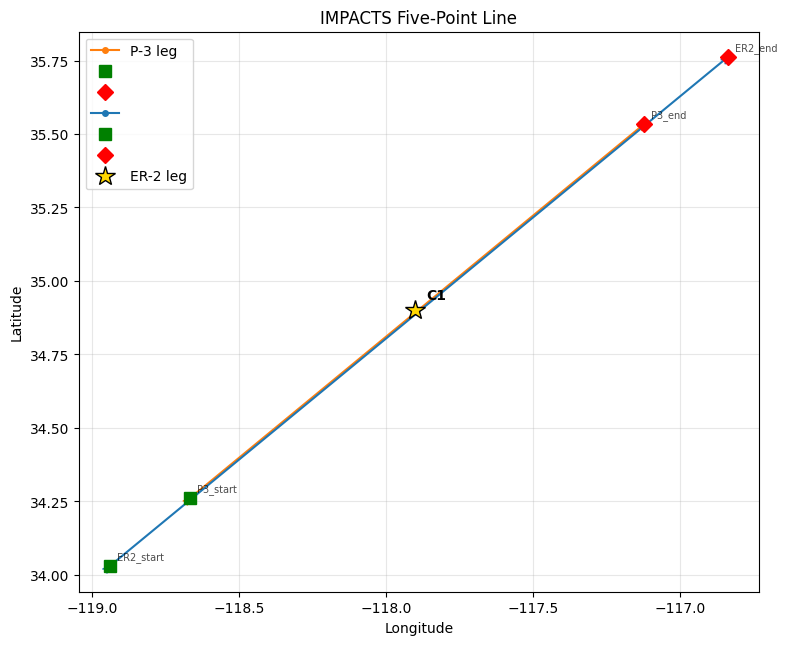

In [32]:
from hyplan import NASA_ER2, NASA_P3, coordinated_line

er2 = NASA_ER2()
p3 = NASA_P3()

# Single five-point line with explicit speed ratio
result = coordinated_line(
    center=CENTER,
    heading=45.0,
    primary_leg_length=ureg.Quantity(200, "km"),
    primary_aircraft=p3,
    secondary_aircraft=er2,
    primary_altitude=ureg.Quantity(5000, "feet"),
    secondary_altitude=ureg.Quantity(65000, "feet"),
    ground_speed_ratio=1.36,
)

fig, ax = plt.subplots(figsize=(8, 8))
# Plot both legs
plot_pattern(result["primary"], ax=ax, title="IMPACTS Five-Point Line", color="C1")
plot_pattern(result["secondary"], ax=ax, color="C0", show_labels=True)

# Mark the coordination center
ax.plot(result["center"].longitude, result["center"].latitude,
        "*", color="gold", markersize=15, zorder=10, markeredgecolor="black")
ax.annotate("C1", (result["center"].longitude, result["center"].latitude),
            textcoords="offset points", xytext=(8, 8), fontsize=10, fontweight="bold")

ax.legend(["P-3 leg", "", "", "", "", "", "ER-2 leg"], loc="upper left")
print(f"Ground speed ratio: {result['ground_speed_ratio']:.2f}")
print(f"P-3 waypoints: {[wp.name for wp in result['primary']]}")
print(f"ER-2 waypoints: {[wp.name for wp in result['secondary']]}")
plt.tight_layout()
plt.show()

### Multi-ratio five-point lines

By 2023, IMPACTS used two five-point lines per leg with different speed
ratios (1.2 for high-altitude P-3, 1.45 for low-altitude P-3), giving
the P-3 pilot altitude flexibility while maintaining coordination.

Speed ratios: [1.2, 1.45]
ER-2 inner waypoints: ['ER2_start_r1', 'ER2_end_r1']
ER-2 outer waypoints: ['ER2_start_r2', 'ER2_end_r2']


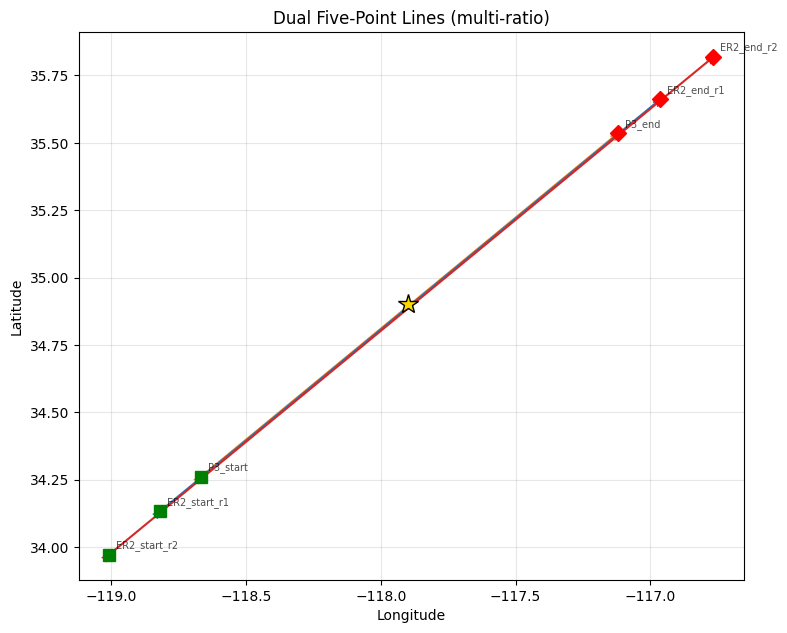

In [33]:
# Multi-ratio: two ER-2 legs for high/low P-3 altitude options
result_multi = coordinated_line(
    center=CENTER,
    heading=45.0,
    primary_leg_length=ureg.Quantity(200, "km"),
    primary_aircraft=p3,
    secondary_aircraft=er2,
    primary_altitude=ureg.Quantity(5000, "feet"),
    secondary_altitude=ureg.Quantity(65000, "feet"),
    ground_speed_ratio=[1.2, 1.45],
)

fig, ax = plt.subplots(figsize=(8, 8))
plot_pattern(result_multi["primary"], ax=ax, title="Dual Five-Point Lines (multi-ratio)", color="C1")
for i, pair in enumerate(result_multi["secondary"]):
    color = "C0" if i == 0 else "C3"
    plot_pattern(pair, ax=ax, color=color, show_labels=True)

ax.plot(result_multi["center"].longitude, result_multi["center"].latitude,
        "*", color="gold", markersize=15, zorder=10, markeredgecolor="black")

print(f"Speed ratios: {result_multi['ground_speed_ratio']}")
print(f"ER-2 inner waypoints: {[wp.name for wp in result_multi['secondary'][0]]}")
print(f"ER-2 outer waypoints: {[wp.name for wp in result_multi['secondary'][1]]}")
plt.tight_layout()
plt.show()

## Summary

| Generator | Key Parameters | Example Patterns |
|-----------|---------------|------------------|
| `racetrack(center, heading, altitude, leg_length, ...)` | `n_legs`, `offset`, `altitudes`, `stack_altitudes` | Racetrack, lawnmower, bowling alley, vertical wall, stacked |
| `rosette(center, heading, altitude, radius, ...)` | `n_lines`, `angles` | 3-petal rosette, cross, bow-tie |
| `polygon(center, heading, altitude, radius, ...)` | `n_sides`, `aspect_ratio`, `closed` | Square, rectangle, hexagon, circle, ellipse |
| `sawtooth(center, heading, altitude_min, altitude_max, ...)` | `leg_length`, `n_cycles` | Porpoising, stepped profiles |
| `spiral(center, heading, altitude_start, altitude_end, ...)` | `radius`, `n_turns`, `direction`, `points_per_turn` | Ascending/descending spirals, constant-altitude orbits |
| `flight_lines_to_waypoint_path(flight_lines, ...)` | `altitude` (override) | Convert FlightLine lists to waypoint paths |
| `coordinated_line(center, heading, primary_leg_length, ...)` | `primary_aircraft`, `secondary_aircraft`, `ground_speed_ratio` | IMPACTS five-point line, dual-aircraft coordination |

All generators produce `Waypoint` objects with `segment_type="pattern"` that flow
directly into `compute_flight_plan()`. Geodesic math (`pymap3d.vincenty`) is used
for all waypoint placement — no flat-earth approximation.